In [1]:
from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import lax
from jax import numpy as jnp
from jax.scipy.fft import dctn, idctn
import numpy as np
from functools import partial

from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast
from uot.utils.central_gradient_nd import _central_gradient_nd

from collections.abc import Sequence
from typing import Optional
from functools import reduce

from uot.data.measure import GridMeasure

from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any

from matplotlib import pyplot as plt

In [ ]:
plt.rcParams['figure.dpi'] = 120  # Set the display DPI for inline plots
plt.rcParams['savefig.dpi'] = 120 # Set the default DPI for saved figures

## Few utility functions

In [3]:
def _wait_jax_finish(result: dict[str, Any]) -> dict[str, Any]:
    """Block until all JAX arrays in `result` are ready."""
    # tree_map was removed and need to use tree.map?
    # ну ебать его в рот, я хуй знает как оно там в джаксе
    return jax.tree.map(
        lambda x: x.block_until_ready() if isinstance(x, jax.Array) else x,
        result
    )


def _row_major_strides_py(shape):
    """Row-major (C-order) strides for flattening (static Python ints)."""
    d = len(shape)
    strides_py = []
    p = 1
    for k in range(d - 1, -1, -1):
        strides_py.insert(0, p)
        p *= shape[k]
    return strides_py


def _cell_centers_physical(shape, dtype):
    """
    Cell centers for n_i cells per axis:
        x_i = (i + 0.5) / n_i
    Returns x with shape (d, *shape).
    """
    d = len(shape)
    idx = jnp.indices(shape, dtype=dtype)  # (d, *shape)
    n_vec = jnp.array(shape, dtype=dtype).reshape((d,) + (1,) * d)
    return (idx + 0.5) / n_vec


def physical_to_index_cell_centered(y: jnp.ndarray, shape, *, clip_eps: float = 1e-6) -> jnp.ndarray:
    """
    Convert physical coords y in [0,1]^d to continuous index coords s suitable for CIC
    on a cell-centered grid (cell masses).

    y:     (d, *shape) physical coords
    shape: tuple of grid sizes (n1, n2, ..., nd)

    Returns:
      s: (d, *shape) continuous index coords where integer j corresponds to cell center.
         (So y=(j+0.5)/n  <=>  s=j.)
    """
    d = len(shape)
    n_vec = jnp.array(shape, dtype=y.dtype).reshape((d,) + (1,) * d)
    y = jnp.clip(y, 0.0, 1.0 - clip_eps)
    s = y * n_vec - 0.5
    return s


## Maybe Lanscoz Noise Diff ?

In [4]:
def _sinc(x):
    # normalized sinc: sin(pi x)/(pi x)
    return jnp.where(x == 0, 1.0, jnp.sin(jnp.pi * x) / (jnp.pi * x))


def lanczos_diff_kernel(radius: int, *, dtype=jnp.float64):
    """
    Low-noise Lanczos differentiator (1st derivative), symmetric odd kernel.
    Support: n in [-radius, ..., +radius], length = 2*radius+1.

    Base ideal differentiator: h[n] = (-1)^n / n for n!=0, h[0]=0
    Window: w[n] = sinc(n / radius) (Lanczos window)
    Kernel: k[n] = h[n] * w[n], then normalized for correct low-freq gain.

    Returns:
      k: (2*radius+1,) kernel with sum(k)=0 and approx correct slope.
    """
    r = int(radius)
    n = jnp.arange(-r, r + 1, dtype=dtype)

    # ideal differentiator impulse response (discrete-time)
    h = jnp.where(n == 0, 0.0, ((-1.0) ** n) / n)

    # Lanczos window (a = radius)
    w = _sinc(n / r)

    k = h * w

    # Normalize so that the first moment matches ~1 (low-frequency gain).
    # For a good derivative operator, we want: sum_n (n * k[n]) ≈ 1
    m1 = jnp.sum(n * k)
    k = jnp.where(m1 != 0, k / m1, k)

    return k


def _conv1d_same_edge(x_1d, k_1d):
    """
    1D convolution with 'SAME' output size using edge padding.
    x_1d: (N,)
    k_1d: (K,)
    """
    K = k_1d.shape[0]
    pad = K // 2
    xpad = jnp.pad(x_1d, (pad, pad), mode="edge")
    # lax.conv wants shapes (N,C) or (N,C,...) with explicit batch; easiest is 1D as (1,1,L)
    x3 = xpad[None, None, :]           # (1,1,Lpad)
    k3 = k_1d[None, None, :]           # (1,1,K)
    y3 = lax.conv_general_dilated(
        x3, k3,
        window_strides=(1,),
        padding="VALID",
        dimension_numbers=("NCH", "OIH", "NCH"),
    )
    return y3[0, 0, :]                 # (N,)


def lanczos_gradient_nd(psi, *, radius=10, coordinates=None, dtype=jnp.float64):
    """
    ND gradient using separable 1D Lanczos differentiator per axis.

    psi: (*shape)
    radius: half-width of kernel (typical 4..10)
    coordinates: optional list of 1D coordinate arrays (cell centers, uniform).
                 If provided, uses h_k = coords[k][1]-coords[k][0].
                 Otherwise uses h_k = 1/shape[k] (your old convention).
    Returns:
      grad: (d, *shape) approximating dpsi/dx in physical units.
    """
    psi = psi.astype(dtype)
    shape = psi.shape
    d = psi.ndim

    k = lanczos_diff_kernel(radius, dtype=dtype)  # (2r+1,)

    if coordinates is None:
        hs = [dtype(1.0) / dtype(shape[ax]) for ax in range(d)]
    else:
        hs = [(coordinates[ax][1] - coordinates[ax][0]).astype(dtype) for ax in range(d)]

    grads = []
    for ax in range(d):
        # Move axis to front, apply 1D conv along that axis for every "line"
        x = jnp.moveaxis(psi, ax, 0)  # (Nax, ...)
        Nax = x.shape[0]
        rest = x.reshape((Nax, -1))   # (Nax, M)

        def one_col(col):
            return _conv1d_same_edge(col, k) / hs[ax]

        # vmap over columns (M lines)
        y = jnp.stack([one_col(rest[:, j]) for j in range(rest.shape[1])], axis=1)
        y = y.reshape(x.shape)
        y = jnp.moveaxis(y, 0, ax)
        grads.append(y)

    return jnp.stack(grads, axis=0).astype(psi.dtype)


## Monge Map Construction

In [5]:
def monge_map_cic_from_psi_nd(psi: jnp.ndarray) -> jnp.ndarray:
    """
    Build a Monge map in index coordinates.
    """
    shape = psi.shape
    d = psi.ndim
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)

    # grad = _central_gradient_nd(psi)
    grad = lanczos_gradient_nd(psi)
    idx = jnp.indices(shape, dtype=jnp.float32)
    # s_raw = idx + 0.5 + grad * n_vec
    # s_raw = idx + grad * n_vec
    s_raw = idx - grad * n_vec
    clipped = []
    for ax in range(d):
        clipped.append(jnp.clip(s_raw[ax], 0.0, shape[ax] - 1.0))
    return jnp.stack(clipped, axis=0)

def monge_map_from_psi_physical_nd(
    psi: jnp.ndarray,
    *,
    dtype_map=jnp.float32,
):
    """
    Build Monge map in physical coords:
        y(x) = x - grad psi(x)
    where x are cell centers.

    Returns:
      y:   (d, *shape) in [0,1]^d (not clamped here)
      grad:(d, *shape) dpsi/dx in physical coords
      x:   (d, *shape) cell-center coords
    """
    shape = psi.shape

    # compute grad in float64 for stability (helps when n is large)
    psi64 = psi.astype(jnp.float64)
    grad64 = _central_gradient_nd(psi64)             # (d, *shape), physical derivative
    x64 = _cell_centers_physical(shape, jnp.float64) # (d, *shape)

    y64 = x64 - grad64

    return y64.astype(dtype_map)
    # return y64.astype(dtype_map), grad64.astype(dtype_map), x64.astype(dtype_map)

In [6]:
def monge_map_cic_clipped_from_psi_nd(
    psi: jnp.ndarray,
    coordinates: list[jnp.ndarray],
    *,
    clip_eps_index: float = 1e-6,   # avoids landing exactly on the last cell edge
) -> jnp.ndarray:
    """
    Build a Monge map in *index coordinates* (center-index coords),
    but clamp the implied physical locations to the real domain
    defined by `coordinates` (cell-centered grid).

    Keeps your index construction:
        s_raw = idx - grad * n_vec
    and keeps the same physical<->index transition:
        y = c0 + h*s,  s = (y - c0)/h

    Args:
      psi:         (*shape)
      coordinates: list of d 1D arrays, each length n_k, UNIFORM cell centers
    Returns:
      s_clipped: (d, *shape) float32, in [0, n_k-1] (approximately), suitable for CIC
    """
    shape = psi.shape
    d = psi.ndim
    assert len(coordinates) == d
    for k in range(d):
        assert coordinates[k].shape[0] == shape[k]

    # Your existing index-space map
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)
    grad = _central_gradient_nd(psi).astype(jnp.float32)     # dpsi/dx on [0,1] per your current grad
    idx = jnp.indices(shape, dtype=jnp.float32)

    s_raw = idx - grad * n_vec  # (d, *shape), index coords

    # Clamp in PHYSICAL coords using coordinates, then return to index coords
    s_out = []
    for ax in range(d):
        c = coordinates[ax].astype(jnp.float32)
        h = c[1] - c[0]
        c0 = c[0]

        # real domain boundaries for cell-centered grid
        xmin = c0 - 0.5 * h
        xmax = c[-1] + 0.5 * h

        # convert index -> physical: y = c0 + h * s
        y_raw = c0 + h * s_raw[ax]

        # clip physical, stay strictly inside xmax to avoid frac==1 later
        y_clipped = jnp.clip(y_raw, xmin, xmax - clip_eps_index * h)

        # convert back physical -> index
        s_clipped = (y_clipped - c0) / h

        # (optional safety) also clip to [0, n-1-eps] in index space
        s_clipped = jnp.clip(s_clipped, 0.0, (shape[ax] - 1.0) - clip_eps_index)

        s_out.append(s_clipped)

    return jnp.stack(s_out, axis=0)


## Pushforward Procedures

In [7]:
# def cic_pushforward_nd(density, psi):
def cic_pushforward_nd(
        density: jnp.ndarray,
        monge_map: jnp.ndarray,
        ) -> jnp.ndarray:
    """
    Pushforward a density field along the flow defined by psi.
    - density: (n_1, n_2, ..., n_d) array of nonnegative values
    - psi:     (n_1, n_2, ..., n_d) array of potential values
    Returns:
    - new_density: (n_1, n_2, ..., n_d) array of nonnegative values
    - grad: (d, n_1, n_2, ..., n_d) array of gradients of psi
    Assumes uniform grid on [0,1]^d with grid spacing h_i = 1/n_i.
    Uses multilinear interpolation (bilinear in 2D, trilinear in 3D, etc).
    Boundary: clamp to [0, n_k - 1] in each dimension.
    0.5*||x||^2 is implicit in the definition of psi.
    1. Compute grad psi
    2. Compute fractional index s = i + grad psi * n
       (vertex-centered interpretation)
    3. Clip s to [0, n_k - 1] in each dimension
    4. Compute base = floor(s) and frac = s - base
    5. Scatter density to 2^d corners with multilinear weights
    """
    shape = density.shape
    d = density.ndim
    mdtype = monge_map.dtype

    base = jnp.floor(monge_map).astype(jnp.int32)
    # No need for additional clipping on base since s is clipped;
    # base will be in [0, n_k - 2] naturally if s in [0, n_k - 1)
    # But to be safe, clip base
    # for ax in range(d):
    #     base_ax = jnp.clip(base[ax], 0, shape[ax] - 2)
    #     base = base.at[ax].set(base_ax)
    # frac = monge_map - base.astype(jnp.float32)  # Now frac guaranteed in [0,1)
    frac = monge_map - base.astype(mdtype)

    # --- flatten using static sizes (no int() on tracers) ---
    density_flat = density.reshape(-1)                     # OK: -1 uses static size
    base_flat    = base.reshape(d, -1)
    frac_flat    = frac.reshape(d, -1)

    strides = jnp.array(
        _row_major_strides_py(shape),
        dtype=jnp.int32,
        ).reshape(d, 1)

    out = jnp.zeros_like(density_flat)

    def corner_body(m, out_acc):
        bits = jnp.array([(m >> k) & 1 for k in range(d)], dtype=jnp.int32).reshape(d, 1)
        corner_idx = base_flat + bits                      # (d,N)
        w = jnp.where(bits == 1, frac_flat, 1.0 - frac_flat)
        w = jnp.prod(w, axis=0)                            # (N,)
        flat_idx = jnp.sum(corner_idx * strides, axis=0)   # (N,)
        return out_acc.at[flat_idx].add(density_flat * w)

    out = lax.fori_loop(0, 1 << d, corner_body, out)
    return out.reshape(shape)

In [8]:
def cic_pushforward_physical_nd(
    density: jnp.ndarray,
    monge_map: jnp.ndarray,
    # psi: jnp.ndarray,
    *,
    clip_eps: float = 1e-6,
    dtype_map=jnp.float64,
    # return_map: bool = False,
):
    """
    Pushforward cell masses using CIC with Monge map:
        y = x - grad psi(x)

    Steps:
      1) x = cell centers in [0,1]^d
      2) y = x - grad psi(x)   (physical coords)
      3) clamp y to [0, 1 - eps]
      4) convert to center-index coords: s = y*n - 0.5
      5) CIC scatter to 2^d corners

    Returns:
      out_density: (*shape) pushed cell masses
      grad:        (d, *shape) physical grad dpsi/dx
      optionally y (physical map) if return_map=True
    """
    shape = density.shape
    d = density.ndim
    y = monge_map

    # --- 1-2) physical map ---
    # y, grad, _x = monge_map_from_psi_physical_nd(psi, dtype_map=dtype_map)

    # --- 3) clamp in physical coords (IMPORTANT: keep strictly below 1) ---
    y = jnp.clip(y, 0.0, 1.0 - clip_eps)

    # --- 4) physical -> center-index coords for raster scatter ---
    # For cell centers: y = (j + 0.5)/n  <=>  j = y*n - 0.5
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)
    s = y * n_vec - 0.5  # (d, *shape)

    base = jnp.floor(s).astype(jnp.int32)
    for ax in range(d):
        base_ax = jnp.clip(base[ax], 0, shape[ax] - 2)
        base = base.at[ax].set(base_ax)
    frac = s - base.astype(jnp.float32)  # in [0,1) if clipping is correct

    # --- 5) flatten + CIC scatter ---
    density_flat = density.reshape(-1)
    base_flat = base.reshape(d, -1)
    frac_flat = frac.reshape(d, -1)

    strides = jnp.array(_row_major_strides_py(shape), dtype=jnp.int32).reshape(d, 1)
    out = jnp.zeros_like(density_flat)

    def corner_body(m, out_acc):
        bits = jnp.array([(m >> k) & 1 for k in range(d)], dtype=jnp.int32).reshape(d, 1)
        corner_idx = base_flat + bits
        w = jnp.where(bits == 1, frac_flat, 1.0 - frac_flat)
        w = jnp.prod(w, axis=0)
        flat_idx = jnp.sum(corner_idx * strides, axis=0)
        return out_acc.at[flat_idx].add(density_flat * w)

    out = lax.fori_loop(0, 1 << d, corner_body, out).reshape(shape)
    return out

In [9]:
def ngp_pushforward_nd(density: jnp.ndarray, monge_map: jnp.ndarray) -> jnp.ndarray:
    """
    NGP (Nearest-Grid-Point) pushforward:
      j = round(s)  (per axis), clamp to [0, n_k-1]
      out[j] += density[i]
    Returns (new_density, grad) with same conventions as your CIC code.
    """
    shape = density.shape
    d = density.ndim

    # grad = _central_gradient_nd(psi)     # (d, *shape)
    # s = monge_map_cic_from_psi_nd(psi)   # (d, *shape), float

    # nearest integer indices
    j = jnp.rint(monge_map).astype(jnp.int32)    # (d, *shape)

    # jax.debug.print("J (Monge rint) max is {} min is {} mean is {}", jnp.max(j), jnp.min(j), jnp.mean(j))

    # clamp indices
    for ax in range(d):
        # jax.debug.print("The number of indices hitting the clamp on ax {} is {}", ax, jnp.mean((j[ax] <= 0) | (j[ax] >= d-1)))
        j_ax = jnp.clip(j[ax], 0, shape[ax] - 1)
        j = j.at[ax].set(j_ax)
        

    # flatten
    density_flat = density.reshape(-1)   # (N,)
    j_flat = j.reshape(d, -1)            # (d, N)

    strides = jnp.array(_row_major_strides_py(shape), dtype=jnp.int32).reshape(d, 1)
    flat_idx = jnp.sum(j_flat * strides, axis=0)  # (N,)

    out = jnp.zeros_like(density_flat)
    out = out.at[flat_idx].add(density_flat)

    return out.reshape(shape)


def binning_pushforward_nd(density: jnp.ndarray, monge_map: jnp.ndarray) -> jnp.ndarray:
    """
    Cell-centered "binning" (floor) pushforward:
      j = floor(s) (per axis), clamp to [0, n_k-1]
      out[j] += density[i]
    """
    shape = density.shape
    d = density.ndim

    # bin indices (lower/left cell)
    j = jnp.floor(monge_map).astype(jnp.int32)   # (d, *shape)

    # clamp indices
    for ax in range(d):
        j_ax = jnp.clip(j[ax], 0, shape[ax] - 1)
        j = j.at[ax].set(j_ax)

    # flatten
    density_flat = density.reshape(-1)   # (N,)
    j_flat = j.reshape(d, -1)            # (d, N)

    strides = jnp.array(_row_major_strides_py(shape), dtype=jnp.int32).reshape(d, 1)
    flat_idx = jnp.sum(j_flat * strides, axis=0)  # (N,)

    out = jnp.zeros_like(density_flat)
    out = out.at[flat_idx].add(density_flat)

    return out.reshape(shape)

In [10]:
@partial(jax.jit, static_argnames=('maxiterations', 'progressbar',
                                  'stepsize_lower_bound', 'error_metric',
                                  'monge_map_fn',
                                  'pushforward_fn'))
def backnforth_sqeuclidean_nd(
        mu: jnp.ndarray,                 # shape (n0,...,nd-1)
        nu: jnp.ndarray,                 # shape (n0,...,nd-1)
        coordinates: list[jnp.ndarray],  # len d, each length n_k
        stepsize: float,
        maxiterations: int,
        tolerance: float,
        progressbar: bool = False,
        pushforward_fn=cic_pushforward_nd,
        monge_map_fn=monge_map_cic_from_psi_nd,
        # pushforward_fn=cic_pushforward_physical_nd,
        stepsize_lower_bound: float = 0.01,
        error_metric: str = 'h1_psi',
    ):
    """
    Dimension-agnostic BFM with quadratic cost on a uniform tensor grid in [0,1]^d.

    error_metric: 'tv_psi' | 'tv_phi' | 'l_inf_psi' | 'h1_psi' | 'h1_psi_relative'
                  | 'transportation_cost' | 'transportation_cost_relative'
    """

    # checks (lightweight; keep in Python tracer-friendly)
    shape = mu.shape
    assert nu.shape == shape
    d = len(coordinates)
    assert d == mu.ndim == nu.ndim
    for k in range(d):
        assert coordinates[k].shape[0] == shape[k]
    init_stepsize = stepsize
    armijo_upper = 0.75
    armijo_lower = 0.25
    armijo_scale_down = 0.95


    # c-transform for quadratic cost (will call your fast implementation)
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # precompute kernel and r^2 grid
    hs = [c[1] - c[0] for c in coordinates]         # cell width
    Ls = [hs[k] * shape[k] for k in range(d)]       # true length = N*h
    # Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)
    xmins = jnp.array([c[0] - 0.5*hs[k] for k,c in enumerate(coordinates)])
    xmaxs = jnp.array([c[-1] + 0.5*hs[k] for k,c in enumerate(coordinates)])
    r2 = _r2_from_coords(coordinates)
    cell_vol = jnp.prod(jnp.array([c[1] - c[0] for c in coordinates], dtype=mu.dtype))
    mu_nu_grid_sum = 0.5 * (r2 * (mu + nu)).sum()


    def dct_neumann_poisson(f):
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,)*f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    def update_potential(phi, rho, target, sigma):
        residual = target - rho
        pde_solution = dct_neumann_poisson(residual)
        new_phi = phi + sigma * pde_solution
        grad_sq = cell_vol * jnp.vdot(residual, pde_solution).real
        return new_phi, pde_solution, grad_sq

    # Dual objective (quadratic cost):  ½∫|x|² (μ+ν) - ∫ν φ - ∫μ ψ
    def dual_value(phi, psi):
        return cell_vol * (mu_nu_grid_sum - (phi * mu).sum() - (psi * nu).sum())

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        # if progressbar:
        #     jax.debug.print("[stepsize_update] gain = {}; up = {}; low = {}; sigma {} -> {}",
        #                     gain, grad_sq * sigma * upper,
        #                     grad_sq * sigma * lower, old_sigma, sigma)
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    def compute_error(iter_idx, dual_curr, dual_prev, grad_curr, grad_prev,
                      rho_mu=None, rho_nu=None):
        if error_metric == 'tv_psi':
            err = 0.5 * jnp.sum(jnp.abs(rho_mu - nu))
        elif error_metric == 'tv_phi':
            err = 0.5 * jnp.sum(jnp.abs(rho_nu - mu))
        elif error_metric == 'l_inf_psi':
            err = jnp.max(jnp.abs(rho_mu - nu))
        elif error_metric == 'h1_psi':
            err = grad_curr
        elif error_metric == 'h1_psi_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(grad_prev - grad_curr) / jnp.maximum(grad_curr, 1e-10),
            )
        elif error_metric == 'transportation_cost':
            err = jnp.abs(dual_prev - dual_curr)
        elif error_metric == 'transportation_cost_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(dual_prev - dual_curr) / jnp.maximum(jnp.abs(dual_curr), 1e-10),
            )
        else:
            raise ValueError(f"Unknown error_metric: {error_metric}")
        return err
    def body(state):
        (i, phi, psi, sigma, dual_prev, grad_prev,
         errors, dual_values, sigma_history) = state

        # monge_map_psi = monge_map_cic_from_psi_nd(-psi)
        # monge_map_psi = monge_map_from_psi_physical_nd(psi)
        monge_map_psi = monge_map_fn(psi)
        rho_mu = pushforward_fn(mu, monge_map_psi)
        phi, _, _ = update_potential(phi, rho_mu, nu, sigma)
        psi = c_transform(phi)
        # phi = c_transform(psi)  # ensure consistency

        # monge_map_phi = monge_map_cic_from_psi_nd(-phi)
        # monge_map_phi = monge_map_from_psi_physical_nd(phi)
        monge_map_phi = monge_map_fn(phi)
        rho_nu = pushforward_fn(nu, monge_map_phi)
        psi, _, grad_sq_psi = update_potential(psi, rho_nu, mu, sigma)
        phi = c_transform(psi)
        # psi = c_transform(phi)  # ensure consistency

        dual_curr = dual_value(phi, psi)
        sigma_new = stepsize_update(sigma, dual_curr, dual_prev, grad_sq_psi)
        err = compute_error(i, dual_curr, dual_prev, grad_sq_psi, grad_prev,
                            rho_mu=rho_mu, rho_nu=rho_nu)

        errors = errors.at[i].set(err)
        dual_values = dual_values.at[i].set(dual_curr)
        sigma_history = sigma_history.at[i].set(sigma_new)

        if progressbar:
            jax.debug.print("[{}] error = {}; dual = {};",
                            i, errors[i], dual_values[i])

        return (i + 1, phi, psi, sigma_new, dual_curr, grad_sq_psi,
                errors, dual_values, sigma_history)

    def cond(state):
        i = state[0]
        errors = state[6]
        curr_error = errors[jnp.maximum(i - 1, 0)]
        return (i < maxiterations) & (curr_error > tolerance)

    phi0 = jnp.zeros_like(mu)
    psi0 = jnp.zeros_like(nu)
    dual0 = dual_value(phi0, psi0)
    grad0 = 0.0

    errors0 = jnp.full((maxiterations,), jnp.inf, dtype=mu.dtype)
    dual_values0 = jnp.full((maxiterations,), dual0, dtype=mu.dtype)
    sigma_history0 = jnp.full((maxiterations,), stepsize, dtype=mu.dtype)

    init_state = (jnp.array(0, dtype=jnp.int32), phi0, psi0,
                  jnp.asarray(init_stepsize, dtype=mu.dtype), dual0, grad0,
                  errors0, dual_values0, sigma_history0)

    state = lax.while_loop(cond, body, init_state)
    iterations, phi, psi, _, _, _, errors, dual_values, sigma_history = state

    rho_mu = pushforward_fn(mu, monge_map_fn(psi))
    rho_nu = pushforward_fn(nu, monge_map_fn(phi))
    results = {
        'iterations': iterations,
        'phi': phi,
        'psi': psi,
        'rho_nu': rho_nu,
        'rho_mu': rho_mu,
        'errors': errors,
        'dual_history': dual_values,
        'sigma_history': sigma_history,
    }
    return results


def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


In [11]:
from uot.problems.generators import GaussianMixtureGenerator
from uot.utils import costs
from uot.utils import generator_helpers

gaussian_params = {
    'dim': 1,
    "n_points": 32,
    "borders": (0.0, 1.0),
    "cell-discretization": "cell-centered",
}

gaussian_generator = GaussianMixtureGenerator(
    name='g',
    dim=gaussian_params['dim'],
    num_components=1,
    n_points=gaussian_params['n_points'],
    num_datasets=15,
    borders=gaussian_params['borders'],
    cost_fn=costs.cost_euclid_squared,
    use_jax=False,
    seed=43,
    measure_mode='grid',
    cell_discretization=gaussian_params['cell-discretization'],
)

grid_axes = generator_helpers.get_axes(
    dim=gaussian_params['dim'],
    borders=gaussian_params['borders'],
    n_points=gaussian_params['n_points'],
    cell_discretization=gaussian_params['cell-discretization'],
    use_jax=False,
    )

# gaussian_problems = list(gaussian_generator.generate())
gaussian_problems = list(gaussian_generator.generate_with_analytic_solution())

grid_axes[0].shape=(32,) gaussian_mu0_density.shape=(32,)


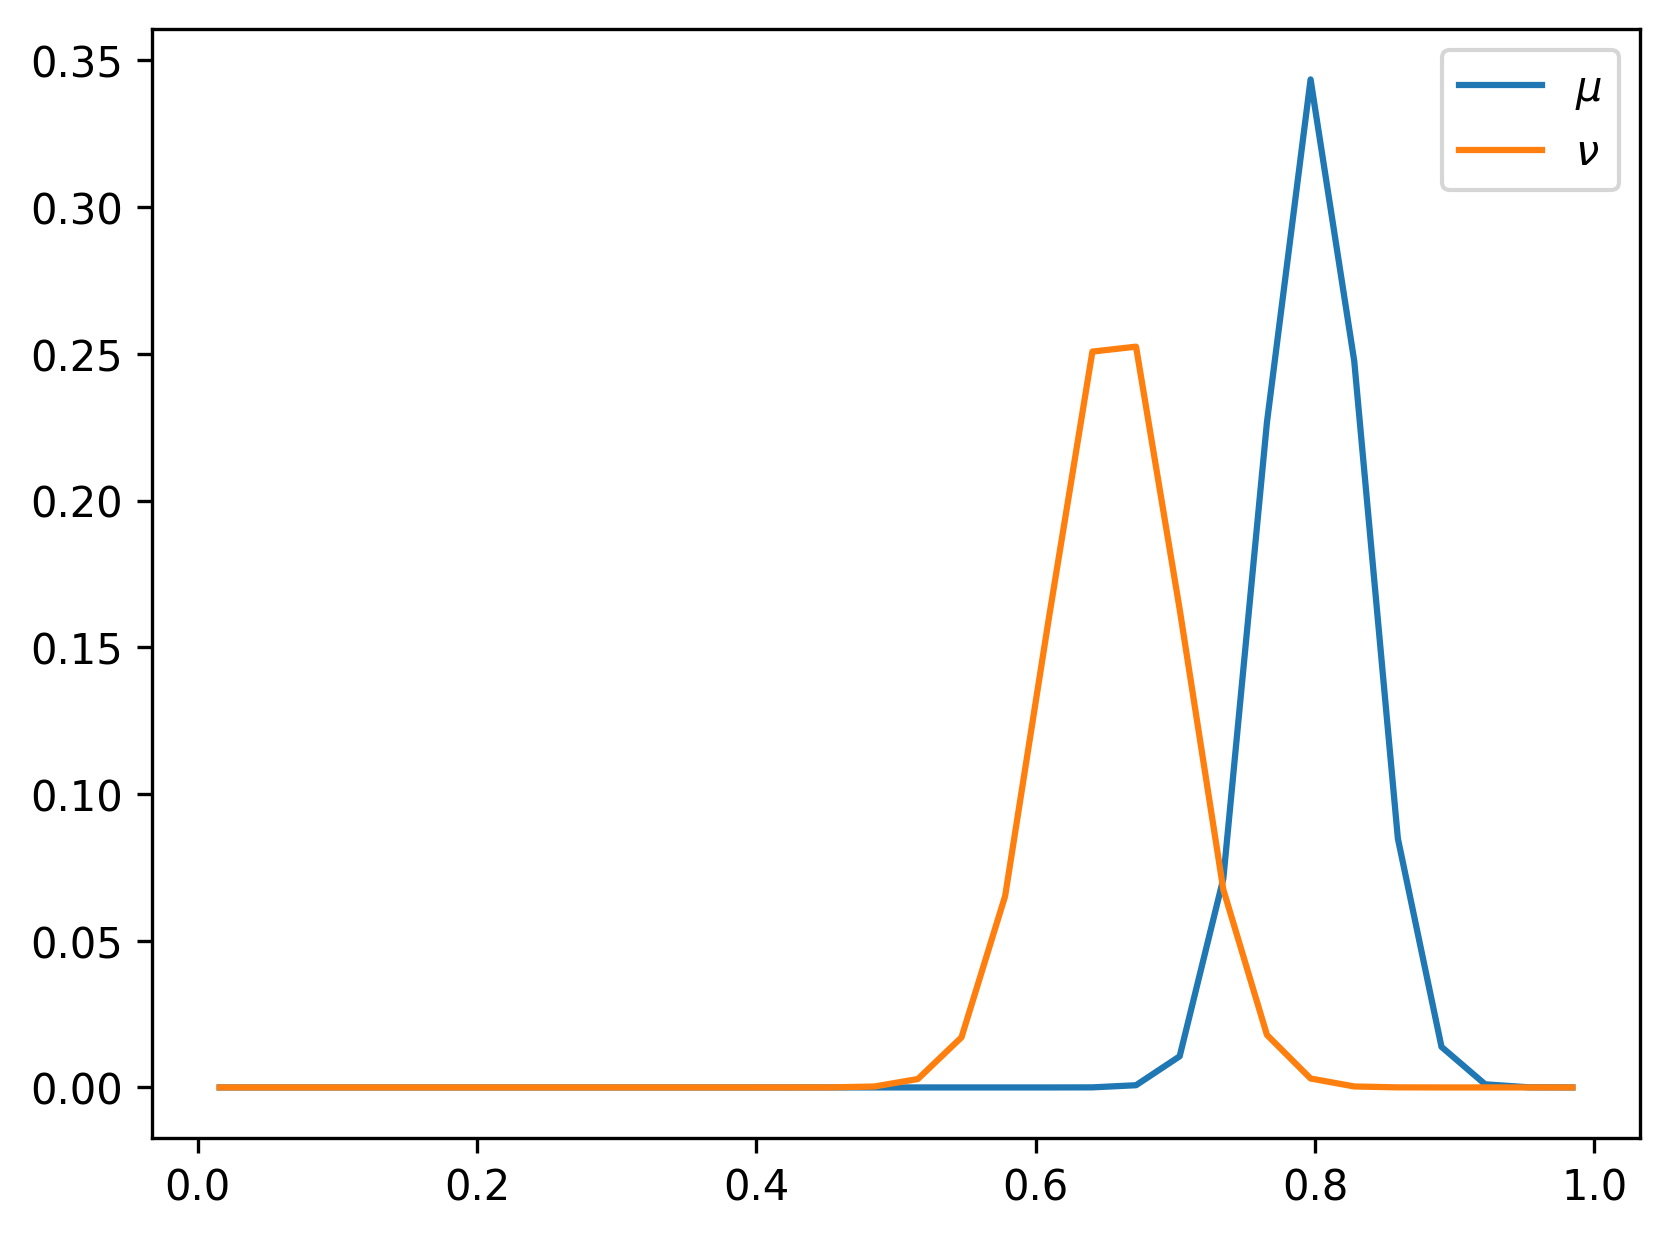

In [12]:
gaussian_problem0, gaussian_problem0_analytic = gaussian_problems[4]
gaussian_mu0, gaussian_nu0 = gaussian_problem0.solver_inputs(include_cost=False).marginals
_, gaussian_mu0_density = gaussian_mu0.as_point_cloud(include_zeros=True)
_, gaussian_nu0_density = gaussian_nu0.as_point_cloud(include_zeros=True)

print(f"{grid_axes[0].shape=} {gaussian_mu0_density.shape=}")

# fig, axs = plt.subplots(nrows=1, ncols=1)
# axs[0].plot(grid_axes[0], gaussian_mu0_density)
plt.plot(grid_axes[0], gaussian_mu0_density, label=r'$\mu$')
plt.plot(grid_axes[0], gaussian_nu0_density, label=r'$\nu$')
plt.legend()

In [13]:
stepsize = 4/jnp.maximum(gaussian_mu0_density.max(), gaussian_nu0_density.sum())
stepsize_lower_bound = 0.01
maxiterations = 300
tolerance = 1e-4
error_metric = 'h1_psi_relative'
# error_metric = 'h1_psi'

results = backnforth_sqeuclidean_nd(
    mu=gaussian_mu0_density,
    nu=gaussian_nu0_density,
    coordinates=grid_axes,
    stepsize=stepsize,
    maxiterations=maxiterations,
    tolerance=tolerance,
    progressbar=True,
    monge_map_fn=partial(monge_map_cic_clipped_from_psi_nd, coordinates=grid_axes),
    pushforward_fn=cic_pushforward_nd,
    stepsize_lower_bound=stepsize_lower_bound,
    error_metric=error_metric,
)
_wait_jax_finish(results)

print(f"Returned keys evailable: {list(results.keys())}")

[0] error = inf; dual = 0.01743233167435701;
[1] error = 15.857720576655481; dual = 0.017480690355797614;
[2] error = 1.29217902785202; dual = 0.017512701208773015;
[3] error = 0.7329544037634897; dual = 0.01753006982817681;
[4] error = 0.157299753232113; dual = 0.01755061616438933;
[5] error = 0.12208211079033437; dual = 0.017567721236185677;
[6] error = 0.1472797749685037; dual = 0.017581362453143578;
[7] error = 0.07595658331557; dual = 0.01759263467817603;
[8] error = 0.04167133396941309; dual = 0.0175996773652513;
[9] error = 0.035045406018288566; dual = 0.01760319702629888;
[10] error = 0.05703675544652268; dual = 0.017605735224392117;
[11] error = 0.05020734976769876; dual = 0.017606930447111875;
[12] error = 0.028673407326451288; dual = 0.017607501337958176;
[13] error = 0.03470054751180483; dual = 0.017610260457252374;
[14] error = 0.1491845697321995; dual = 0.017613420972161425;
[15] error = 0.0008053655458519412; dual = 0.017614237965097677;
[16] error = 0.00710582232759022;

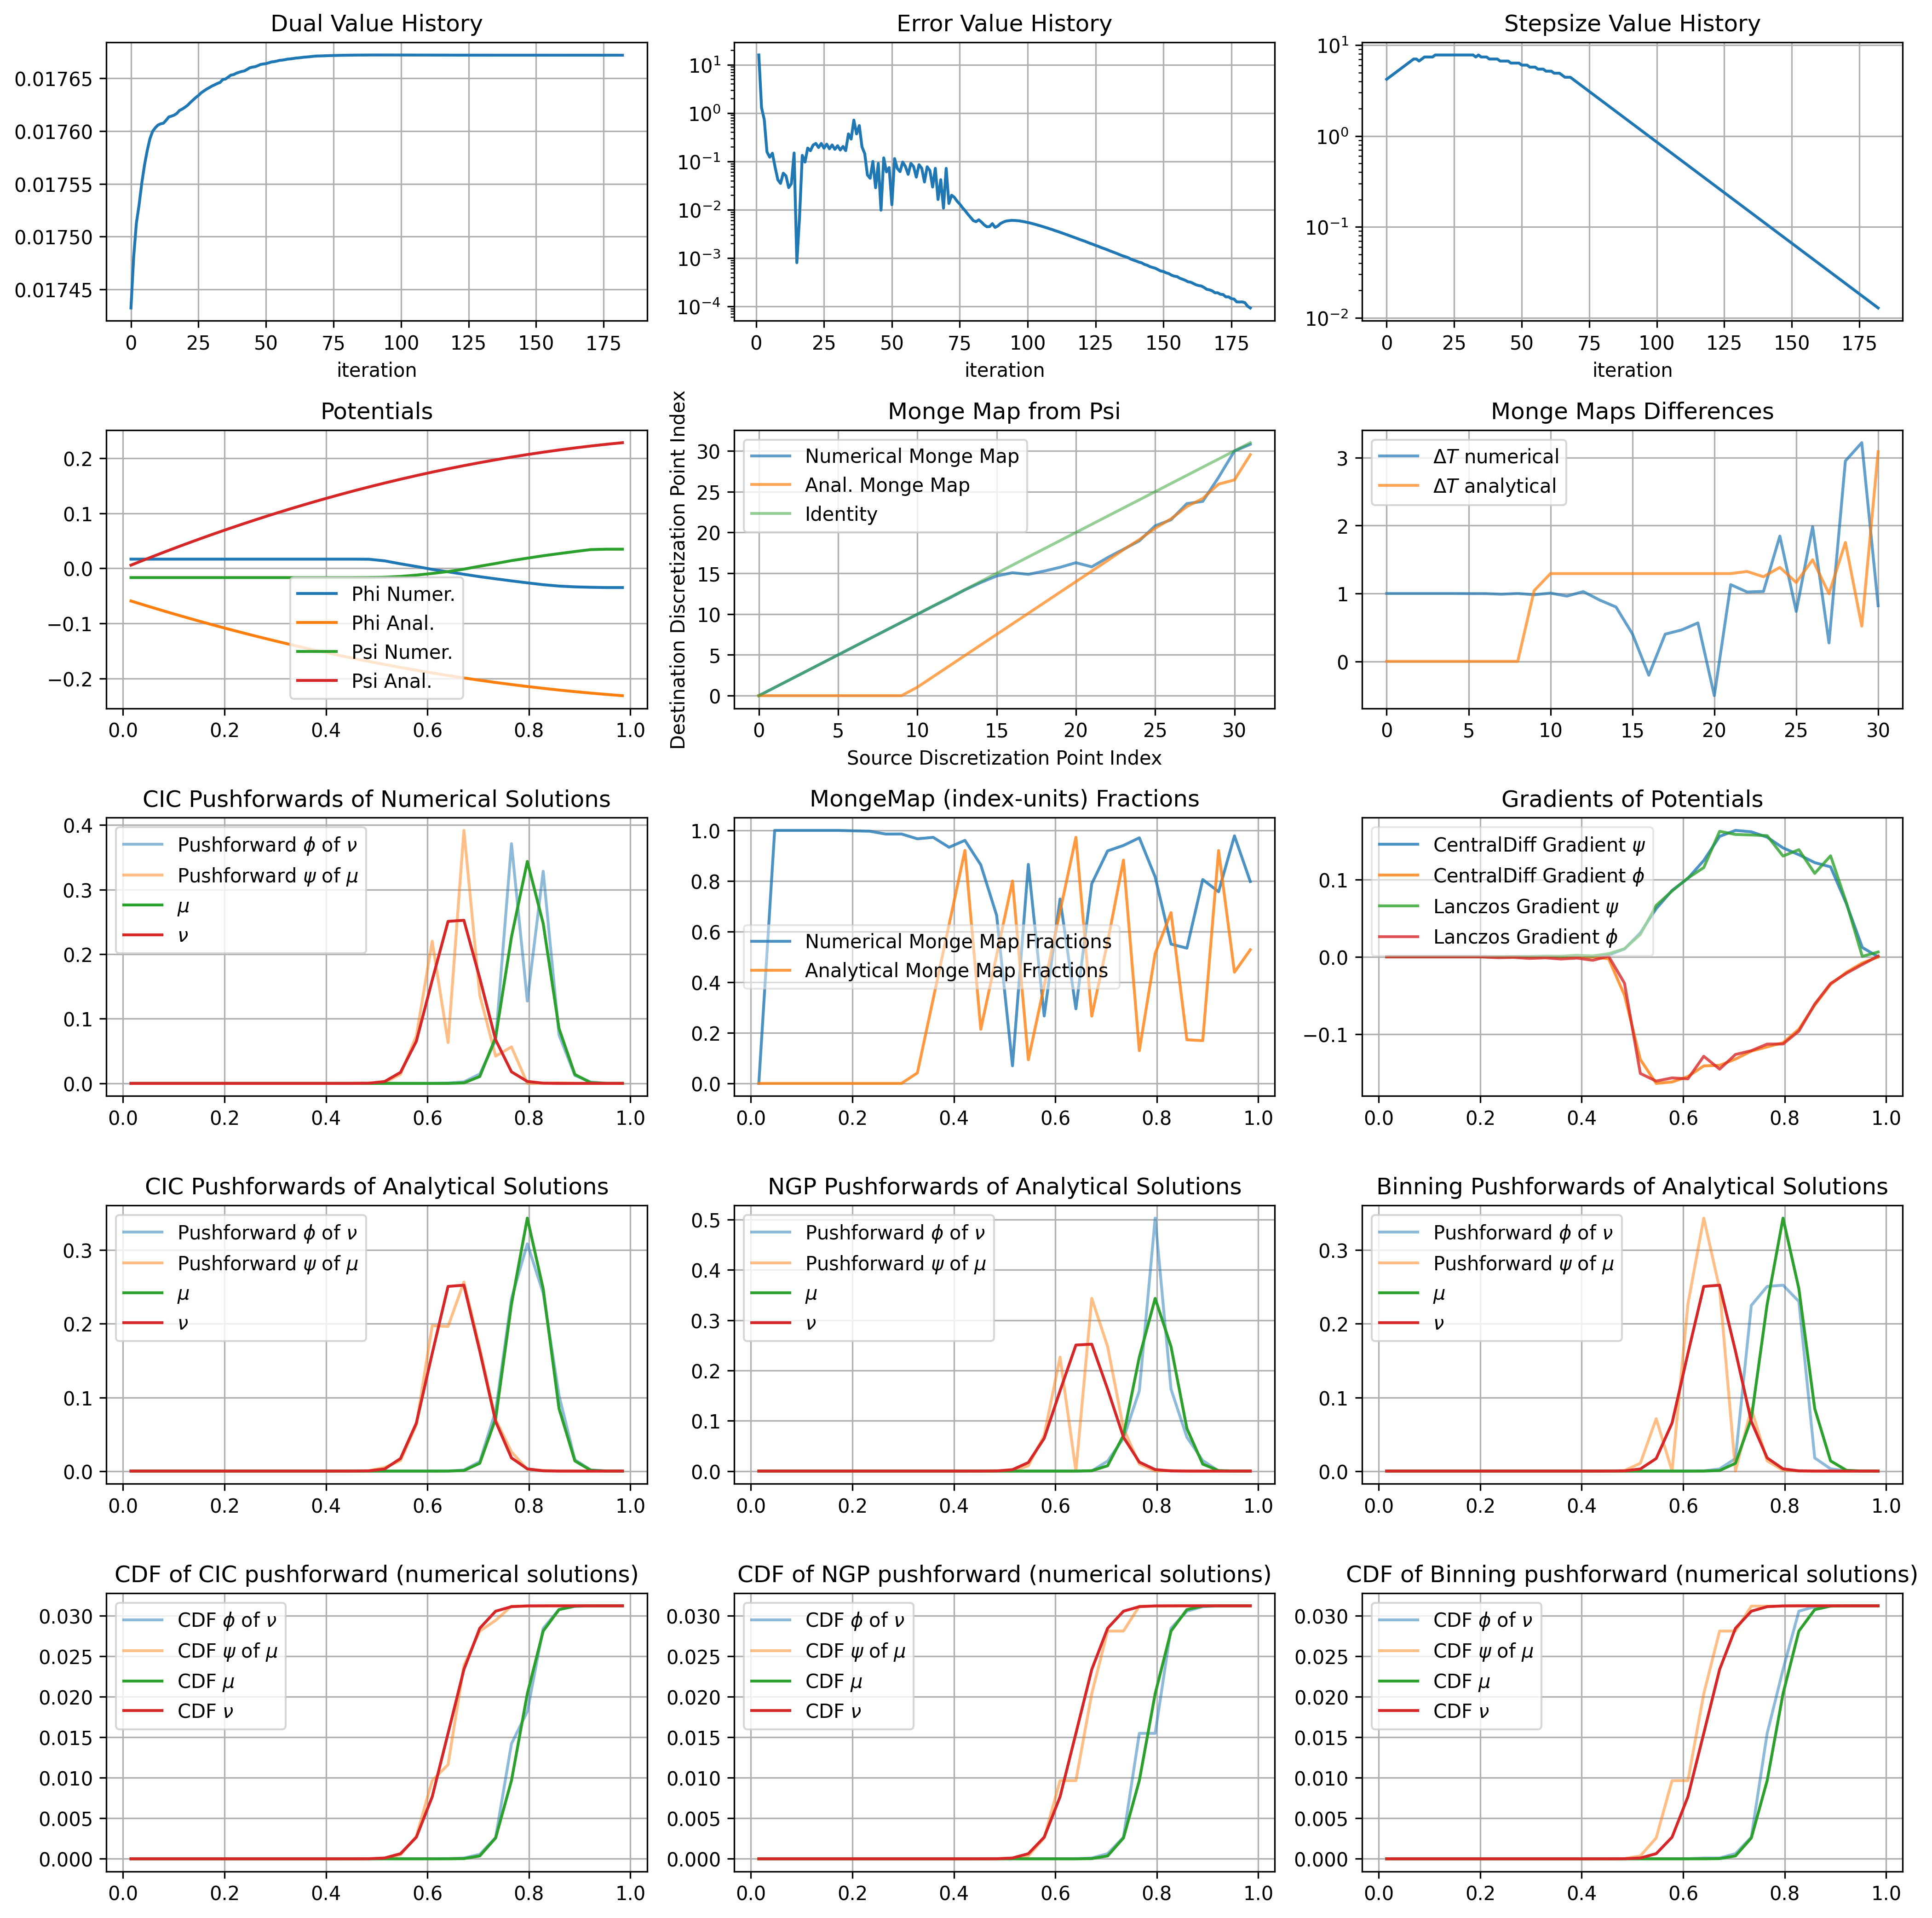

In [14]:
iters = results['iterations']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(14, 14))
[ax.grid() for axxss in axs for ax in axxss]

axs[0][0].plot(results['dual_history'][:iters], label='Dual')
axs[0][0].set_xlabel('iteration')
axs[0][0].set_title('Dual Value History')
axs[0][1].plot(results['errors'][:iters], label='Error')
axs[0][1].set_yscale('log')
axs[0][1].set_xlabel('iteration')
axs[0][1].set_title('Error Value History')
axs[0][2].plot(results['sigma_history'][:iters], label='Stepsize')
axs[0][2].set_yscale('log')
axs[0][2].set_xlabel('iteration')
axs[0][2].set_title('Stepsize Value History')

# --- POTENTIALS ---
axs[1][0].plot(grid_axes[0], results['phi'], label='Phi Numer.')
axs[1][0].plot(grid_axes[0], gaussian_problem0_analytic['phi'], label='Phi Anal.')
# axs[1][0].set_title('Potentials Phi')
# axs[1][0].legend()
axs[1][0].plot(grid_axes[0], results['psi'], label='Psi Numer.')
axs[1][0].plot(grid_axes[0], gaussian_problem0_analytic['psi'], label='Psi Anal.')
# axs[1][0].set_title('Potentials Psi')
axs[1][0].set_title('Potentials')
axs[1][0].legend()

# --- MONGE MAPS ---
monge_map_psi = monge_map_cic_from_psi_nd(results['psi']).reshape((gaussian_params['n_points'],))
monge_map_psi_anal = monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']).reshape((gaussian_params['n_points'],))
# monge_map_psi = physical_to_index_cell_centered(
#     y=monge_map_from_psi_physical_nd(results['psi']).reshape((gaussian_params['n_points'],)),
#     shape=[len(ax) for ax in grid_axes],
# )
# monge_map_psi_anal = physical_to_index_cell_centered(
#     y=monge_map_from_psi_physical_nd(gaussian_problem0_analytic['psi']).reshape((gaussian_params['n_points'],)),
#     shape=[len(ax) for ax in grid_axes],
# )

# monge_map_psi = monge_map_from_psi_physical_nd(results['psi']).reshape((gaussian_params['n_points'],))
# monge_map_psi_anal = monge_map_from_psi_physical_nd(gaussian_problem0_analytic['psi']).reshape((gaussian_params['n_points'],))

axs[1][1].plot(monge_map_psi, alpha=0.7, label='Numerical Monge Map')
axs[1][1].plot(monge_map_psi_anal, alpha=0.7, label='Anal. Monge Map')
axs[1][1].plot(jnp.arange(len(monge_map_psi)), alpha=0.5, label='Identity')
# axs[1][1].plot(jnp.linspace(gaussian_params['borders'][0], gaussian_params['borders'][1], gaussian_params['n_points']), alpha=0.5, label='Identity')
axs[1][1].set_xlabel('Source Discretization Point Index')
axs[1][1].set_ylabel('Destination Discretization Point Index')
axs[1][1].set_title('Monge Map from Psi')
axs[1][1].legend()

diff_monge_numer = monge_map_psi[1:] - monge_map_psi[:-1]
diff_monge_anal = monge_map_psi_anal[1:] - monge_map_psi_anal[:-1]
axs[1][2].plot(diff_monge_numer, alpha=0.7, label='$\\Delta T$ numerical')
axs[1][2].plot(diff_monge_anal, alpha=0.7, label='$\\Delta T$ analytical')
axs[1][2].set_title('Monge Maps Differences')
axs[1][2].legend()

# -------------------------------
# -------- PUSHFORWARDS ---------
# -------------------------------
pushforwards_opacity = 0.5

rho_numer_phi = cic_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = cic_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
# rho_numer_phi = cic_pushforward_physical_nd(gaussian_nu0_density, monge_map_from_psi_physical_nd(results['phi']))
# rho_numer_psi = cic_pushforward_physical_nd(gaussian_mu0_density, monge_map_from_psi_physical_nd(results['psi']))
axs[2][0].plot(grid_axes[0], rho_numer_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[2][0].plot(grid_axes[0], rho_numer_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[2][0].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[2][0].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[2][0].legend()
axs[2][0].set_title('CIC Pushforwards of Numerical Solutions')

# rho_numer_phi = ngp_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
# rho_numer_psi = ngp_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
# axs[2][1].plot(grid_axes[0], rho_numer_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
# axs[2][1].plot(grid_axes[0], rho_numer_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
# axs[2][1].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
# axs[2][1].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
# axs[2][1].legend()
# axs[2][1].set_title('NGP Pushforwards of Numerical Solutions')

# rho_numer_phi = binning_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
# rho_numer_psi = binning_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
# axs[2][2].plot(grid_axes[0], rho_numer_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
# axs[2][2].plot(grid_axes[0], rho_numer_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
# axs[2][2].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
# axs[2][2].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
# axs[2][2].legend()
# axs[2][2].set_title('Binning Pushforwards of Numerical Solutions')

# instead of the pushforwards above lets plot some other debugging information

grad_psi_central = _central_gradient_nd(results['psi']).reshape(-1)
grad_phi_central = _central_gradient_nd(results['phi']).reshape(-1)
grad_psi_lanczos = lanczos_gradient_nd(results['psi']).reshape(-1)
grad_phi_lanczos = lanczos_gradient_nd(results['phi']).reshape(-1)
axs[2][2].plot(grid_axes[0], grad_psi_central, alpha=0.8, label='CentralDiff Gradient $\\psi$')
axs[2][2].plot(grid_axes[0], grad_phi_central, alpha=0.8, label='CentralDiff Gradient $\\phi$')
axs[2][2].plot(grid_axes[0], grad_psi_lanczos, alpha=0.8, label='Lanczos Gradient $\\psi$')
axs[2][2].plot(grid_axes[0], grad_phi_lanczos, alpha=0.8, label='Lanczos Gradient $\\phi$')
axs[2][2].legend(framealpha=0.5, fancybox=True)
axs[2][2].set_title('Gradients of Potentials')


def get_frac_from_monge(monge_map: jnp.ndarray, d: int = 1) -> jnp.ndarray:
    shape = monge_map.shape
    base = jnp.floor(monge_map).astype(jnp.int32)
    for ax in range(d):
        base_ax = jnp.clip(base[ax], 0, shape[ax] - 2)
        base = base.at[ax].set(base_ax)
    frac = monge_map - base.astype(jnp.float32)  # Now frac guaranteed in [0,1)
    return frac

monge_map_psi = monge_map_cic_from_psi_nd(results['psi']).reshape((gaussian_params['n_points'],))
monge_map_psi_anal = monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']).reshape((gaussian_params['n_points'],))
monge_numer_fractions = get_frac_from_monge(monge_map_psi)
monge_anal_fractions = get_frac_from_monge(monge_map_psi_anal)
axs[2][1].plot(grid_axes[0], monge_numer_fractions, alpha=0.8, label='Numerical Monge Map Fractions')
axs[2][1].plot(grid_axes[0], monge_anal_fractions, alpha=0.8, label='Analytical Monge Map Fractions')
# axs[2][1].grid()
axs[2][1].legend(framealpha=0.5, fancybox=True)
axs[2][1].set_title('MongeMap (index-units) Fractions')

# -------------------------------
# --- ANALYTICAL PUSHFORWARDS ---
# -------------------------------
rho_anal_phi = cic_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['phi']))
rho_anal_psi = cic_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']))
axs[3][0].plot(grid_axes[0], rho_anal_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[3][0].plot(grid_axes[0], rho_anal_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[3][0].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[3][0].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[3][0].legend()
axs[3][0].set_title('CIC Pushforwards of Analytical Solutions')

rho_anal_phi = ngp_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['phi']))
rho_anal_psi = ngp_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']))
axs[3][1].plot(grid_axes[0], rho_anal_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[3][1].plot(grid_axes[0], rho_anal_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[3][1].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[3][1].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[3][1].legend()
axs[3][1].set_title('NGP Pushforwards of Analytical Solutions')

rho_anal_phi = binning_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['phi']))
rho_anal_psi = binning_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(gaussian_problem0_analytic['psi']))
axs[3][2].plot(grid_axes[0], rho_anal_phi, alpha=pushforwards_opacity, label='Pushforward $\\phi$ of $\\nu$')
axs[3][2].plot(grid_axes[0], rho_anal_psi, alpha=pushforwards_opacity, label='Pushforward $\\psi$ of $\\mu$')
axs[3][2].plot(grid_axes[0], gaussian_mu0_density, label='$\\mu$')
axs[3][2].plot(grid_axes[0], gaussian_nu0_density, label='$\\nu$')
axs[3][2].legend()
axs[3][2].set_title('Binning Pushforwards of Analytical Solutions')

# ---- CDF FUNCTIONS ----
mu_cdf = jnp.cumsum(gaussian_mu0_density) * (grid_axes[0][1] - grid_axes[0][0])
nu_cdf = jnp.cumsum(gaussian_nu0_density) * (grid_axes[0][1] - grid_axes[0][0])

rho_numer_phi = cic_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = cic_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
rho_numer_phi_cdf = jnp.cumsum(rho_numer_phi) * (grid_axes[0][1] - grid_axes[0][0])
rho_numer_psi_cdf = jnp.cumsum(rho_numer_psi) * (grid_axes[0][1] - grid_axes[0][0])
axs[4][0].plot(grid_axes[0], rho_numer_phi_cdf, alpha=pushforwards_opacity, label='CDF $\\phi$ of $\\nu$')
axs[4][0].plot(grid_axes[0], rho_numer_psi_cdf, alpha=pushforwards_opacity, label='CDF $\\psi$ of $\\mu$')
axs[4][0].plot(grid_axes[0], mu_cdf, label='CDF $\\mu$')
axs[4][0].plot(grid_axes[0], nu_cdf, label='CDF $\\nu$')
axs[4][0].legend()
axs[4][0].set_title('CDF of CIC pushforward (numerical solutions)')

rho_numer_phi = ngp_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = ngp_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
rho_numer_phi_cdf = jnp.cumsum(rho_numer_phi) * (grid_axes[0][1] - grid_axes[0][0])
rho_numer_psi_cdf = jnp.cumsum(rho_numer_psi) * (grid_axes[0][1] - grid_axes[0][0])
axs[4][1].plot(grid_axes[0], rho_numer_phi_cdf, alpha=pushforwards_opacity, label='CDF $\\phi$ of $\\nu$')
axs[4][1].plot(grid_axes[0], rho_numer_psi_cdf, alpha=pushforwards_opacity, label='CDF $\\psi$ of $\\mu$')
axs[4][1].plot(grid_axes[0], mu_cdf, label='CDF $\\mu$')
axs[4][1].plot(grid_axes[0], nu_cdf, label='CDF $\\nu$')
axs[4][1].legend()
axs[4][1].set_title('CDF of NGP pushforward (numerical solutions)')

rho_numer_phi = binning_pushforward_nd(gaussian_nu0_density, monge_map_cic_from_psi_nd(results['phi']))
rho_numer_psi = binning_pushforward_nd(gaussian_mu0_density, monge_map_cic_from_psi_nd(results['psi']))
rho_numer_phi_cdf = jnp.cumsum(rho_numer_phi) * (grid_axes[0][1] - grid_axes[0][0])
rho_numer_psi_cdf = jnp.cumsum(rho_numer_psi) * (grid_axes[0][1] - grid_axes[0][0])
axs[4][2].plot(grid_axes[0], rho_numer_phi_cdf, alpha=pushforwards_opacity, label='CDF $\\phi$ of $\\nu$')
axs[4][2].plot(grid_axes[0], rho_numer_psi_cdf, alpha=pushforwards_opacity, label='CDF $\\psi$ of $\\mu$')
axs[4][2].plot(grid_axes[0], mu_cdf, label='CDF $\\mu$')
axs[4][2].plot(grid_axes[0], nu_cdf, label='CDF $\\nu$')
axs[4][2].legend()
axs[4][2].set_title('CDF of Binning pushforward (numerical solutions)')

fig.tight_layout()